# AG-HYPOPT · Trial 14

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Thirteen trials recorded; best is trial 12 (0.0150). Sequence: 01 0.0981, 02 0.0246, 03 0.0477, 04 0.0262, 05 0.0196, 06 0.0329, 07 0.0205, 08 0.0294, 09 0.0182, 10 0.0301, 11 0.0174, 12 0.0150, 13 0.0339. Trials 05/07/08/09/10/11/12/13 are all the same plateau point (lr_mu ~27, sigma_ref ~6.1-6.3, lr_gamma ~0.42, gamma_anneal ~0.37-0.43) and span 0.0150-0.0339. mu is tightly bounded at 14.4-17.2% across these runs, while gamma ranges 9.6-21.4%, so essentially all the objective variance comes from the low-count Trans05 scans (trial 13 collapsed at 1nW Trans05, -50.3%; trial 12 was benign and gave the best). No hyperparameter value has beaten the plateau; lr_mu peaks near 27 and sigma_ref is monotone (smaller better). We are in the TPE phase (14th trial).]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_14'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (13/5 trials)
ID |     ei | params
 1 | 3.9750 | {"gamma_anneal": 0.37762579665469276, "lr_gamma": 0.41663500737622366, "lr_mu": 26.989236641717834, "sigma_ref": 6.1876052510650394}
 2 | 3.9998 | {"gamma_anneal": 0.41734599219490254, "lr_gamma": 0.4174386844399097, "lr_mu": 27.04917503454812, "sigma_ref": 6.0954568659031985}
 3 | 3.9985 | {"gamma_anneal": 0.48764563563539154, "lr_gamma": 0.41870348498146964, "lr_mu": 26.999031972703758, "sigma_ref": 6.146901868067178}
 4 | 3.9315 | {"gamma_anneal": 0.4158583439219237, "lr_gamma": 0.8970587074805996, "lr_mu": 5.736670970523138, "sigma_ref": 6.173062767115909}
 5 | 3.9968 | {"gamma_anneal": 0.3890329189606368, "lr_gamma": 0.4193616763440038, "lr_mu": 27.094276081825626, "sigma_ref": 6.217819371021598}
 6 | 3.7575 | {"gamma_anneal": 0.1379754038882086, "lr_gamma": 0.8550987059497606, "lr_mu": 26.917323130183572, "sigma_ref": 6.175499695223736}
 7 | 3.9785 | {"gamma_anneal": 0.42725020604379654, "lr_gamma": 0.41904090302008

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best is trial 12 (0.0150); the plateau config gives mu 14.4-17.2% and gamma 9.6-21.4% across its runs, with the objective spread tracing to the Trans05 low-count scans. The TPE batch again concentrates on the plateau: the top-ei draws #2 (ei 3.9998, lr_mu 27.05, sigma_ref 6.095), #8 (3.9994) and #3 (3.9985) are effectively the same point, and the off-plateau candidates drop lr_mu or raise sigma_ref into regions already shown poor. The sensible choice is the model's top draw, candidate 2, which sits at the low-sigma_ref edge of the plateau (sigma_ref 6.095, matching trial 12's best) with the optimal lr_mu; it repeats the winning configuration to add another sample of the floor, which is what the campaign must do given that single-run noise exceeds the tunable effects. I choose candidate 2.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 2               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.41734599219490254, 'lr_gamma': 0.4174386844399097, 'lr_mu': 27.04917503454812, 'sigma_ref': 6.0954568659031985}
Running  1nW Trans05 ... 

μ 9.39 -> 6.90 | γ 8.5 -> 6.87 | NLL 1.32


Running  1nW Trans20 ... 

μ 17.32 -> 15.87 | γ 8.5 -> 7.93 | NLL 2.75


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 97.95 | γ 14.1 -> 13.85 | NLL 3.64


Running 3nW Trans100 ... 

μ 175.71 -> 161.12 | γ 14.1 -> 13.78 | NLL 2.88



Total: 7.1 min


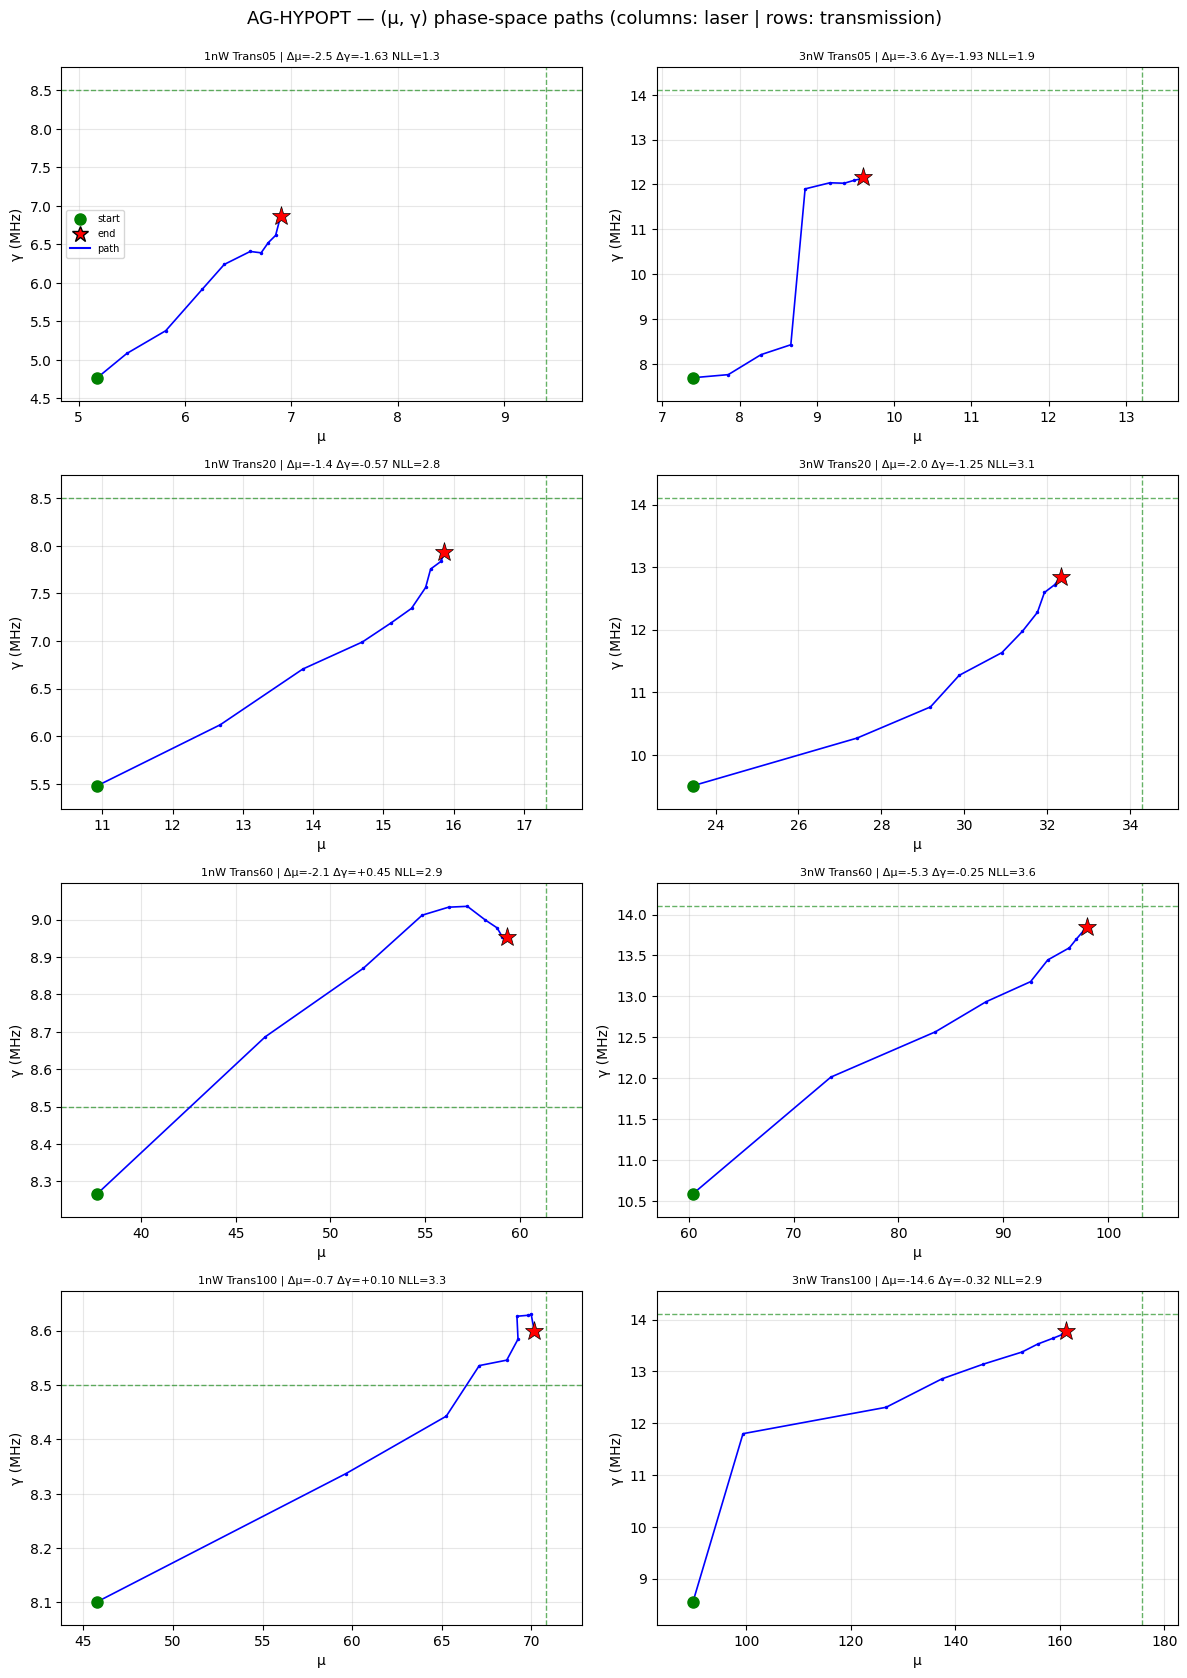

trial finished in 7.1 min
objective = 0.0149 ± 0.0061
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.90   -26.5 |     8.50    6.87   -19.2
1nW Trans20    17.32   15.87    -8.4 |     8.50    7.93    -6.7
1nW Trans60    61.37   59.29    -3.4 |     8.50    8.95    +5.3
1nW Trans100   70.82   70.17    -0.9 |     8.50    8.60    +1.2
3nW Trans05    13.20    9.59   -27.3 |    14.10   12.17   -13.7
3nW Trans20    34.28   32.32    -5.7 |    14.10   12.85    -8.9
3nW Trans60   103.20   97.95    -5.1 |    14.10   13.85    -1.7
3nW Trans100  175.71  161.12    -8.3 |    14.10   13.78    -2.3

μ: RMSE 5.812 (rel 14.4%, bias -4.009) | γ: RMSE 1.039 (rel 9.5%, bias -0.674)


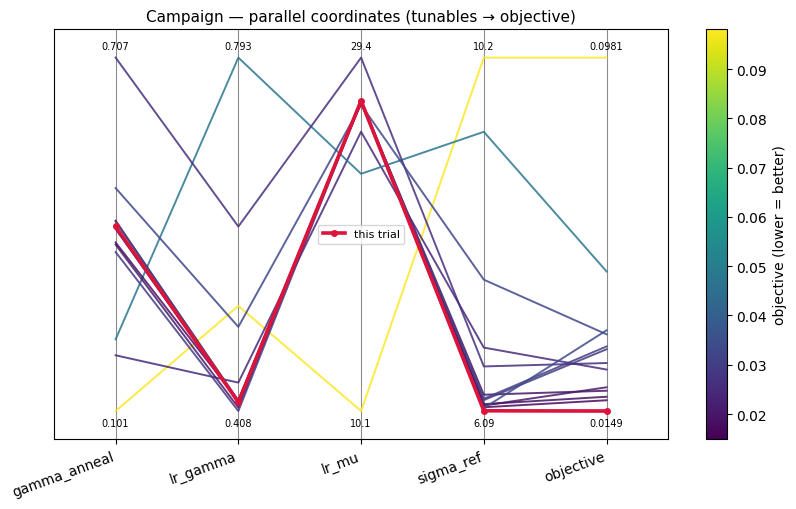

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 14 (sigma_ref 6.095, lr_mu 27.05, lr_gamma 0.417, gamma_anneal 0.417), a top-ei plateau draw at the low-sigma_ref edge, ran 7.1 min and scored 0.0149 +/- 0.0061, the new best by a hair over trial 12 (0.0150). It is essentially trial 12's config (sigma_ref 6.095 vs 6.093) with the same signature: mu 14.4% (floor) and gamma 9.5% (best; 3nW Trans05 -13.7%). The two best trials in the campaign are now the two lowest-sigma_ref plateau points (6.09), and both have gamma below 10%, versus 11.6-21.4% for the other plateau runs. That strengthens the case that sigma_ref just below 6.1 is the optimum edge, though the Trans05 noise still dominates run-to-run. Trials 12 and 14 are statistically tied as best; the plateau (lr_mu ~27, sigma_ref ~6.1, lr_gamma ~0.42, gamma_anneal ~0.42) is the campaign optimum.

**Summary:** Trial 14 (sigma_ref 6.095, lr_mu 27.05, lr_gamma 0.417, gamma_anneal 0.417) scored 0.0149 +/- 0.0061, the new best by a hair over trial 12 (0.0150) and again with gamma under 10% (9.5%) at the low-sigma_ref edge.
**Key insight:** Both best trials sit at the low-sigma_ref edge (6.09) with gamma under 10%, while other plateau runs give gamma 11.6-21.4% - sigma_ref ~6.1 looks like the optimum, though Trans05 noise still dominates.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 14 (sigma_ref 6.095, lr_mu 27.05, lr_gamma 0.417, gamma_anneal 0.417) scored 0.0149 +/- 0.0061, the new best by a hair over trial 12 (0.0150) and again with gamma under 10% (9.5%) at the low-sigma_ref edge.'
KEY_INSIGHT = 'Both best trials sit at the low-sigma_ref edge (6.09) with gamma under 10%, while other plateau runs give gamma 11.6-21.4% - sigma_ref ~6.1 looks like the optimum, though Trans05 noise still dominates.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_14 | current best: trial_14


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_15.ipynb. Open it and follow its cells from the top.
